## Исследовательский анализ данных Яндекс.Афиша

- Автор: Владимиров Николай Александрович
- Дата: 01.02.2026

##  Цели и задачи проекта

Провести исследовательский анализ данных, чтобы выявить инсайты об изменении пользовательских предпочтений и популярности событий осенью 2024 года, а также проверить гипотезы о разнице в поведении пользователей с мобильными и стационарными устройствами.

## Описание данных

Данные о бронировании билетов на сервисе Яндекс Афиша за период с 1 июня по 30 октября 2024 года.

Два датасета final_tickets_orders_df.csv - включает информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных

final_tickets_events_df.csv - содержит информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия.

## Загрузка данных

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_orders_df.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

Данные полные пропусков нет

In [4]:
df['order_id'] = df['order_id'].astype('int32')
df['event_id'] = df['event_id'].astype('int32')
df['age_limit'] = df['age_limit'].astype('int8')
df['tickets_count'] = df['tickets_count'].astype('int8')

In [5]:
display(df.head())

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


In [6]:
events = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_events_df.csv')

In [7]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


In [8]:
events['event_id'] = events['event_id'].astype('int32')
events['city_id'] = events['city_id'].astype('int16')
events['venue_id'] = events['venue_id'].astype('int32')

In [9]:
display(events.head())

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


данные полные пропусков нет

In [10]:
dup_events = events["event_id"].duplicated().sum()
print(f"Дубликатов : {dup_events}")

Дубликатов : 0


In [11]:
tenge = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

In [12]:
tenge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


In [13]:
display(tenge.head())

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


Данные выгружены правильно и полностью.

Пропусков нет.

У некоторых столбцов понизил разрядность и и привел к нужному формату. 

## Предобработка данных и подготовка их к исследованию

In [14]:
#Объединение датафреймов
df = df.merge(events, on='event_id', how='left')

In [15]:
#перевод тенге в рубли
df['created_dt_msk'] = pd.to_datetime(df['created_dt_msk'])
tenge['data'] = pd.to_datetime(tenge['data'])
df['date'] = df['created_dt_msk'].dt.date
tenge['date'] = tenge['data'].dt.date

In [16]:
df = df.merge(tenge[['date', 'curs']], on='date', how='left')

In [17]:
duplicates = df['order_id'].duplicated().sum()
print(f"\nКоличество дубликатов: {duplicates}")


Количество дубликатов: 0


In [18]:
print("Уникальные значения в категориальных столбцах для проверки неявных дубликатов:")
print("event_type_description:", df['event_type_description'].unique())
print("event_type_main:", df['event_type_main'].unique())
print("service_name:", df['service_name'].unique())
print("region_name:", df['region_name'].unique())
print("currency_code:", df['currency_code'].unique())
print("device_type_canonical:", df['device_type_canonical'].unique())
print("age_limit:", df['age_limit'].unique())

Уникальные значения в категориальных столбцах для проверки неявных дубликатов:
event_type_description: ['спектакль' 'событие' 'цирковое шоу' 'выставка' 'шоу' 'концерт' 'спорт'
 'мюзикл' 'фестиваль' nan 'ёлка' 'балет' 'спортивное мероприятие' 'опера'
 'музыкальный спектакль' 'кукольный спектакль' 'оперетта' 'снегурочка'
 'рок-мюзикл' 'экскурсия' 'подарок']
event_type_main: ['театр' 'выставки' 'другое' 'стендап' 'концерты' 'спорт' nan 'ёлки']
service_name: ['Край билетов' 'Мой билет' 'За билетом!' 'Лови билет!'
 'Билеты без проблем' 'Облачко' 'Лучшие билеты' 'Прачечная' 'Быстробилет'
 'Дом культуры' 'Весь в билетах' 'Билеты в руки' 'Тебе билет!'
 'Show_ticket' 'Городской дом культуры' 'Яблоко' 'Билет по телефону'
 'Выступления.ру' 'Росбилет' 'Шоу начинается!' 'Мир касс' 'Восьмёрка'
 'Телебилет' 'Crazy ticket!' 'Реестр' 'Быстрый кассир' 'КарандашРУ'
 'Радио ticket' 'Дырокол' 'Вперёд!' 'Кино билет' 'Цвет и билет' 'Зе Бест!'
 'Тех билет' 'Лимоны' 'Билеты в интернете']
region_name: ['Каменев

Данные чистые, неявных дубликатов не обнаружено.

Можно конечно объединить шоу и цирковое шоу, спорт и спортивное мероприятие, опера и оперетта, я в этом не разбираюсь.Стоит ли это объединять и проводить последующий анализ на каких данных. Оставлю как есть пока что.

In [19]:
duplicates = df.duplicated(subset=df.columns.difference(['order_id'])).sum()
print(f"\nКоличество дубликатов (по всем признакам кроме order_id): {duplicates}")


Количество дубликатов (по всем признакам кроме order_id): 30


In [20]:
print(f"Было строк: {len(df)}")

df = df.sort_values('created_ts_msk')

df = df.drop_duplicates(subset = ['user_id', 'event_id', 'created_ts_msk'], keep='first')

print(f"Строк стало: {len(df)}")

Было строк: 290849
Строк стало: 290729


In [21]:
print(f"Удалено дубликатов: {duplicates}")

Удалено дубликатов: 30


____________________________________________________________
В df было обнаружено 30 дубликатов и удалено.

In [22]:
df['curs'].fillna(df['curs'].mean(), inplace=True)

In [23]:
#перевод тенге в рубли
df['revenue_rub'] = np.where(df['currency_code'] == 'rub', df['revenue'], df['revenue'] * (df['curs'] / 100))
df['total_rub'] = np.where(df['currency_code'] == 'rub', df['total'], df['total'] * (df['curs'] / 100))

df.drop(['date', 'curs'], axis=1, inplace=True)

In [24]:
df = df[df['revenue_rub']>= 0]

Отсеил отрицательные значения, возможно это ошибки или возвраты.

In [25]:
df['one_ticket_revenue_rub'] = df['revenue_rub'] / df['tickets_count']

In [26]:
df['month'] = df['created_dt_msk'].dt.month

In [27]:
df['season'] = np.where(df['month'].isin([6,7,8]), 'лето', 'осень')

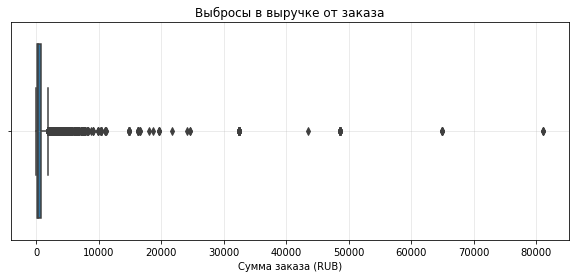

In [28]:
#Проверяем выбросы
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['revenue_rub'])
plt.title('Выбросы в выручке от заказа')
plt.xlabel('Сумма заказа (RUB)')
plt.grid(True, alpha=0.3)
plt.show()

In [29]:
display(df.describe())

,order_id,event_id,age_limit,revenue,tickets_count,total,days_since_prev,city_id,venue_id,revenue_rub,total_rub,one_ticket_revenue_rub,month
count,2.903500e+05,290350.000000,290350.000000,290350.000000,290350.000000,290350.000000,268448.000000,290112.000000,290112.000000,290350.000000,290350.000000,290350.000000,290350.000000
mean,4.326729e+06,438003.460747,10.219618,625.964413,2.755120,7537.015054,3.225187,916.153441,2710.600220,555.937425,6481.938753,201.319821,8.551145
std,2.497638e+06,147434.633426,6.514571,1227.879218,1.170452,15335.629881,11.361276,3559.964063,1086.688246,875.723143,8798.942185,302.930692,1.390011
min,1.000000e+00,4436.000000,0.000000,0.000000,1.000000,-184.170000,0.000000,-28397.000000,894.000000,0.000000,-184.170000,0.000000,6.000000
25%,2.163408e+06,361718.000000,6.000000,116.990000,2.000000,2165.880000,0.000000,39.000000,1706.000000,114.240000,2120.030000,46.850000,7.000000
50%,4.328236e+06,498282.000000,12.000000,356.660000,3.000000,4779.410000,0.000000,79.000000,2786.000000,351.740000,4714.560000,149.950000,9.000000
75%,6.488367e+06,546269.000000,16.000000,810.410000,4.000000,8956.930000,1.000000,213.000000,3676.000000,802.250000,8929.380000,308.700000,10.000000
max,8.653108e+06,592325.000000,18.000000,81174.540000,57.000000,811745.400000,148.000000,29463.000000,4677.000000,81174.540000,811745.400000,21757.540000,10.000000


Очень сильное скошение вправо. обычный чек маленький, но есть редкие заказы на десятки тысяч - выбросы начинаются уже после 1 500-2 000 руб


Выбросы в tickets_count:
count    290350.000000
mean          2.755120
std           1.170452
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          57.000000
Name: tickets_count, dtype: float64


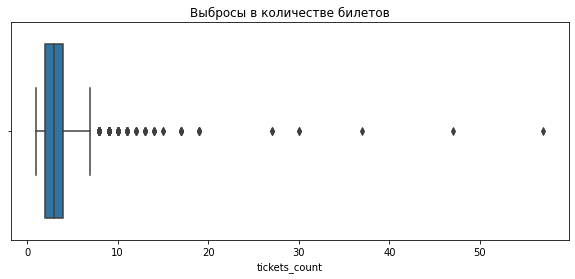

In [30]:
print("\nВыбросы в tickets_count:")
print(df['tickets_count'].describe())
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['tickets_count'])
plt.title('Выбросы в количестве билетов')
plt.show()

Медиана и 75% перцентиль = 3 - типичный заказ 2-3 билета.
Значения >= 5 встречаются редко.
57 билетов вполне возможная покупка. 

In [31]:
#Фильтрация выбросов по 99-му перцентилю
revenue_99 = np.percentile(df['revenue_rub'], 99)
df = df[df['revenue_rub'] <= revenue_99]
print(f'После фильтрации: {len(df)} строк')

После фильтрации: 287525 строк


290729 - 287525 = 3204 Отфильтрованных строк


Дубликаты удалены (по всем кроме order_id).

Выбросы изучены: revenue скошено вправо, tickets_count — редкие группы >4.

Неявные дубликаты в категориях отсутствуют.

Валюты переведены, отрицательные удалены как аномалии.

Данные готовы к анализу.

## Исследовательский анализ данных

### Анализ распределения заказов по сегментам и их сезонные изменения

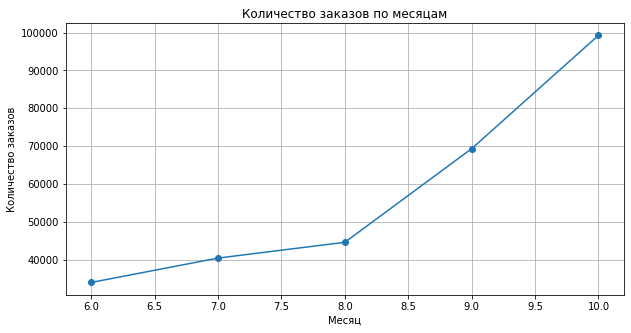

In [32]:
#по месяцам
monthly_orders = df.groupby('month')['order_id'].count()
plt.figure(figsize=(10, 5))
monthly_orders.plot(kind='line', marker='o')
plt.title('Количество заказов по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')
plt.grid(True)
plt.show()

По графику видно резкое увеличение заказов в сентябре с пиком в октябре, что говорит нам о сезонности осенью. 

Июнь - август дают относительно мало заказов, это период когда пользователи в отпусках или тратят деньги на тчо-то другое. 



<Figure size 1008x504 with 0 Axes>

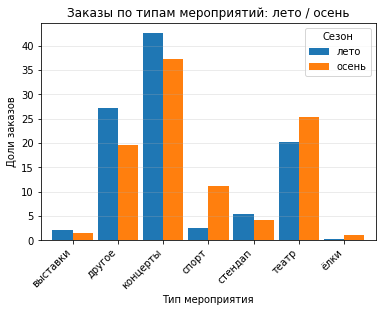

In [33]:
#сезонность и тип мероприятия
season_event = df.groupby(['season', 'event_type_main'])['order_id'].count().unstack(fill_value=0)
season_event_sh = season_event.div(season_event.sum(axis=1), axis=0) * 100

plt.figure(figsize=(14, 7))
season_event_sh.T.plot(kind='bar', width=0.9)
plt.title('Заказы по типам мероприятий: лето / осень')
plt.ylabel('Доли заказов')
plt.xlabel('Тип мероприятия')
plt.legend(title='Сезон')
plt.grid(True, axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.show()

Осенью 2024 спрос на мероприятия выше, чем летом в направлениях театр и спорт. У выставок и стендапов нет выраженной сезонности. Направление концерты имеет большую долю заказов летом, чем осенью.

Театр/спорт растут осенью (культурный сезон). Старт спортивных мероприятий на закрытых площадках.

Концерты - летом проводится больше таких мероприятий, особенно многодневных массовых фестивалей музыки, на которые продаются большое количество билетов. Осенью из-за погодных условий открытых мероприятий намного меньше. 

Выставки/стендапы стабильны

<Figure size 720x432 with 0 Axes>

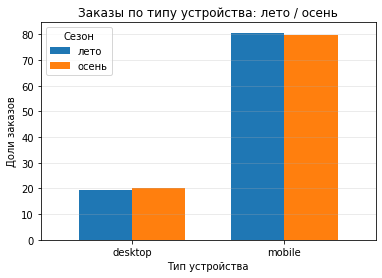

In [34]:
#сезонность типа устройств
season_device = df.groupby(['season', 'device_type_canonical'])['order_id'].count().unstack(fill_value=0)
season_device_sh = season_device.div(season_device.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10, 6))
season_device_sh.T.plot(kind='bar', width=0.7)
plt.title('Заказы по типу устройства: лето / осень')
plt.ylabel('Доли заказов')
plt.xlabel('Тип устройства')
plt.legend(title='Сезон')
plt.xticks(rotation=0)
plt.grid(True, axis='y', alpha=0.3)
plt.show()

Нет сезонности — мобильные/десктоп стабильны круглый год.

<Figure size 864x576 with 0 Axes>

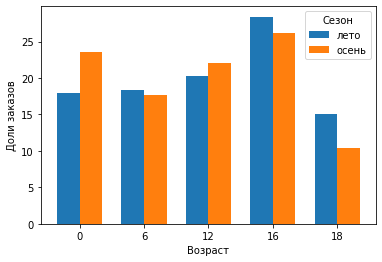

In [35]:
#по возрастному ограничению
season_age = df.groupby(['season', 'age_limit'])['order_id'].count().unstack(fill_value=0)
season_age_sh = season_age.div(season_age.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12, 8))
season_age_sh.T.plot(kind='bar', width=0.7)
plt.xlabel('Возраст')
plt.legend(title='Сезон')
plt.ylabel('Доли заказов')
plt.xticks(rotation = 0)
plt.show()

Заметный прирост осенью — в категориях 0+ и 12+

16+ и 18+ - категории, где количество заказов осенью меньше чем летом

Осенний всплеск спроса связан с семейной / детской / подростковой аудиторией (0-12).
Когда все возвращаются из отпусков и начинается учебный год или детские садики. 

18+ и 16+ возможно это более взрослые концерты/стендапы/выставки. 

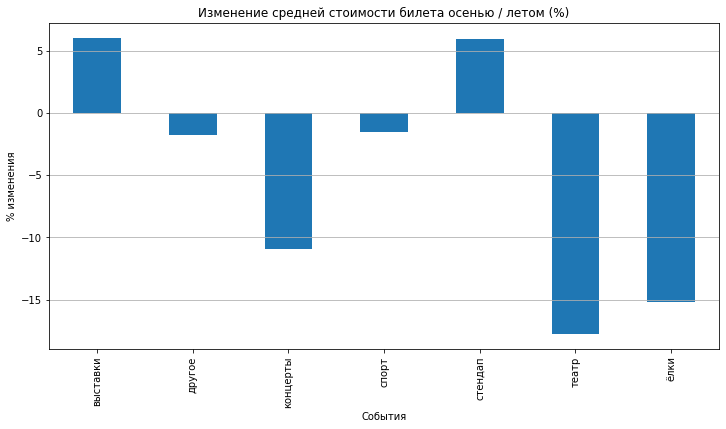

In [36]:
ticket_rev = df.groupby(['season', 'event_type_main'])['one_ticket_revenue_rub'].mean().unstack().fillna(0)
share_ticket_rev = (ticket_rev.loc['осень'] - ticket_rev.loc['лето']) / ticket_rev.loc['лето'] * 100
plt.figure(figsize=(12, 6))
share_ticket_rev.plot(kind='bar')
plt.title('Изменение средней стоимости билета осенью / летом (%)')
plt.ylabel('% изменения')
plt.xlabel('События')
plt.grid(True, axis='y')
plt.show()

Осенью билеты стали дешевле почти во всех категориях, кроме выставок и стендапа. Самое сильное снижение — в театре, ёлки и концерты.

осенью люди чаще покупают больше билетов, но на более бюджетные / массовые события - средний чек падает

Дешевле осенью — массовые/бюджетные события

### Осенняя активность пользователей

In [37]:
autumn_df = df[df['season'] == 'осень'].copy()
autumn_df['day'] = autumn_df['created_dt_msk'].dt.date

In [38]:
#дневная динамика

daily = autumn_df.groupby(autumn_df['created_dt_msk'].dt.date).agg(
    orders=('order_id', 'count'),
    users=('user_id', 'nunique')
)

In [39]:

daily['orders_per_user'] = daily['orders'] / daily['users']
daily['avg_ticket_price'] = autumn_df.groupby(autumn_df['created_dt_msk'].dt.date)['one_ticket_revenue_rub'].mean()

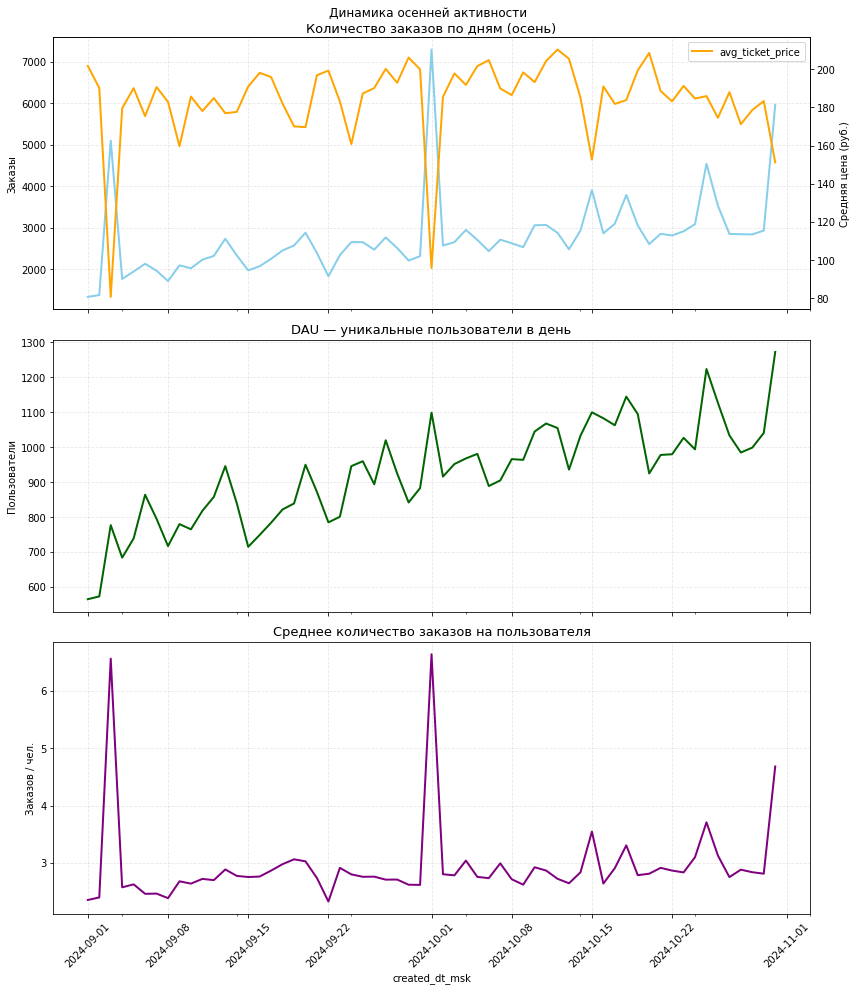

In [40]:
fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)
ax_twin = axes[0].twinx()
# 1. Количество заказов
daily['orders'].plot(ax=axes[0], color='skyblue', linewidth=2)
axes[0].set_title('Количество заказов по дням (осень)', fontsize=13)
axes[0].set_ylabel('Заказы')

# 2. DAU (уникальные пользователи)
daily['users'].plot(ax=axes[1], color='darkgreen', linewidth=2)
axes[1].set_title('DAU — уникальные пользователи в день', fontsize=13)
axes[1].set_ylabel('Пользователи')

# 3. Заказы на одного пользователя
daily['orders_per_user'].plot(ax=axes[2], color='purple', linewidth=2)
axes[2].set_title('Среднее количество заказов на пользователя', fontsize=13)
axes[2].set_ylabel('Заказов / чел.')

# 4. Средняя цена одного билета
daily['avg_ticket_price'].plot(ax=ax_twin, color='orange', linewidth=2)
ax_twin.set_ylabel('Средняя цена (руб.)')
ax_twin.legend()

for ax in axes:
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Динамика осенней активности')
plt.xlabel('Дата')
plt.tight_layout()
plt.show()

В обычные дни цены находятся в диапозоне 180-200 руб. Есть просадки до 100-80 руб. В эти дни и большие пики заказов. Возможно круные акции / промо на билеты. 

DAU постепенно растет к ноябрю. 

In [41]:
autumn_df['day_of_week'] = autumn_df['created_dt_msk'].dt.dayofweek

In [42]:
#Среднее число заказов на одного пользователя по дням недели
weekly_orders_per_user = autumn_df.groupby('day_of_week').apply(lambda x: x['order_id'].count() /x['user_id'].nunique()).reset_index(name='orders_per_user')

# Средняя стоимость одного билета по дням недели
weekly_avg_ticket_price = autumn_df.groupby('day_of_week')['one_ticket_revenue_rub'].mean().reset_index(name='avg_ticket_price')

In [43]:
weekly_orders = autumn_df.groupby('day_of_week')['order_id'].count().reset_index(name='orders')

weekly_users = autumn_df.groupby('day_of_week')['user_id'].nunique().reset_index(name='dau')

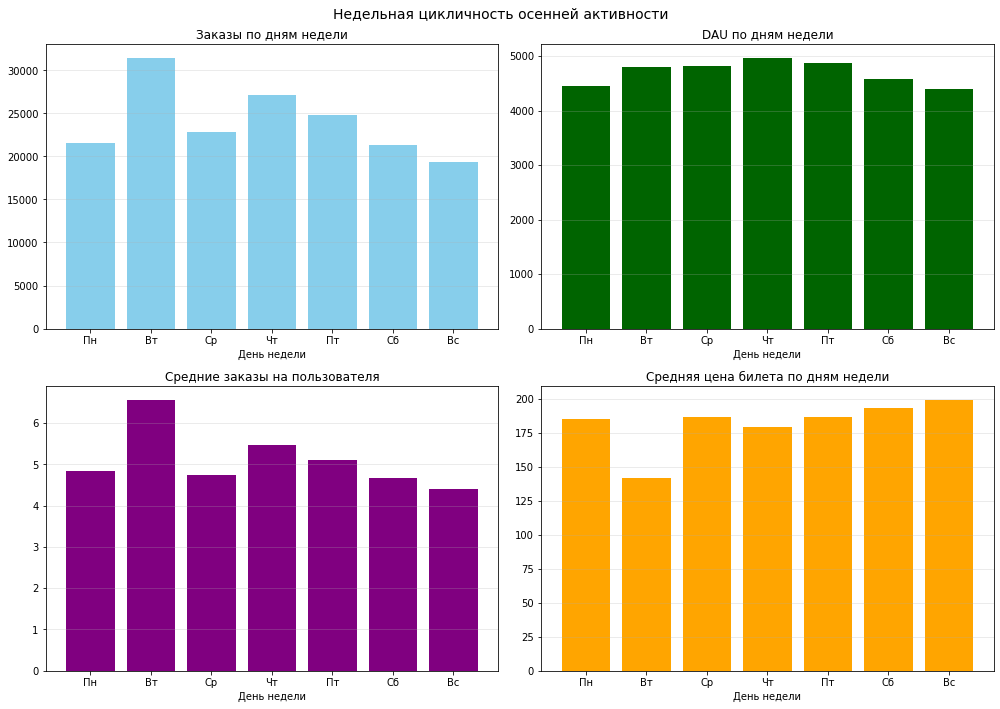

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Недельная цикличность осенней активности', fontsize=14)

# Заказы
axes[0, 0].bar(weekly_orders['day_of_week'], weekly_orders['orders'], color='skyblue')
axes[0, 0].set_title('Заказы по дням недели')
axes[0, 0].set_xticks(range(7))
axes[0, 0].set_xticklabels(['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'], rotation=0)

# DAU
axes[0, 1].bar(weekly_users['day_of_week'], weekly_users['dau'], color='darkgreen')
axes[0, 1].set_title('DAU по дням недели')
axes[0, 1].set_xticks(range(7))
axes[0, 1].set_xticklabels(['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'], rotation=0)

# Заказы на пользователя
axes[1, 0].bar(weekly_orders_per_user['day_of_week'], weekly_orders_per_user['orders_per_user'], color='purple')
axes[1, 0].set_title('Средние заказы на пользователя')
axes[1, 0].set_xticks(range(7))
axes[1, 0].set_xticklabels(['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'], rotation=0)

# Средняя цена билета
axes[1, 1].bar(weekly_avg_ticket_price['day_of_week'], weekly_avg_ticket_price['avg_ticket_price'], color='orange')
axes[1, 1].set_title('Средняя цена билета по дням недели')
axes[1, 1].set_xticks(range(7))
axes[1, 1].set_xticklabels(['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'], rotation=0)

for ax in axes.flatten():
    ax.grid(True, axis='y', alpha=0.3)
    ax.set_xlabel('День недели')

plt.tight_layout()
plt.show()

Конверсия в будни больше чем в выходные дни - пользователи планиуют как провести выходные на неделе.

Во вторник заказов больше чем в любой другой день недели, но от четверга небольшой разрыв, проводились промо акции? как раз 01.10 был большой объем заказов с снижением цен. -  На графике средних цен видна большая просадка вов вторник. 

DAU в выходные остается на высоких значениях, но заказов мыло. Цены на выходных выше чем в будни. Возможно заходят пользователи, которые : 
- кто уже купили билеты. 
- находятся в компании / на отдыхе и не хотят сейчас оформлять заказ
- откладывают на потом (и часто забывают)

Рекомендация:

Напоминания для тех, кто добавил в избранное, но не купил - в субботу вечером и воскресенье

Можно тестировать "воскресные акции" до 23:59 воскресенья — скидка 20%, чтобы подтолкнуть к покупке перед началом рабочей недели.


### Популярные события и партнёры

In [45]:
## регионы
regions = df.groupby('region_name').agg(unique_events=('event_id', 'nunique'),
orders=('order_id', 'count')).sort_values('orders', ascending=False)
regions['events_share'] = regions['unique_events'] / regions['unique_events'].sum()*100
regions['orders_share'] = regions['orders'] / regions['orders'].sum()*100
print(regions.head(10))

                         unique_events  orders  events_share  orders_share
region_name                                                               
Каменевский регион                5940   89723     26.639160     31.231138
Североярская область              3798   43726     17.032918     15.220320
Широковская область               1225   16100      5.493766      5.604152
Медовская область                  503   13885      2.255808      4.833146
Озернинский край                   349   10404      1.565163      3.621466
Светополянский округ              1068    7482      4.789667      2.604364
Малиновоярский округ               165    6509      0.739977      2.265679
Речиновская область                701    6263      3.143780      2.180050
Солнечноземская область            521    6240      2.336532      2.172044
Яблоневская область                534    6118      2.394834      2.129578


Почти половина трафика приходится на два региона - Каменевский регион и Североярская область.

Широковская область имеет хорошее соотношение событий и заказов.

Малиновоярский округ при маленьком количестве событий имеет хороший процент заказов.

In [46]:
# партнеры
partners = df.groupby('service_name').agg(unique_events=('event_id', 'nunique'),
orders=('order_id', 'count'),revenue=('revenue_rub', 'sum')).sort_values('revenue', ascending=False)

partners['events_share'] = partners['unique_events'] / partners['unique_events'].sum() *100
partners['orders_share'] = partners['orders'] / partners['orders'].sum()*100
partners['revenue_share'] = partners['revenue'] / partners['revenue'].sum()*100
display(partners.head(10))

,unique_events,orders,revenue,events_share,orders_share,revenue_share
service_name,,,,,,
Билеты без проблем,4219,63002,2.484839e+07,17.331471,21.911834,16.671996
Мой билет,1302,34134,2.105776e+07,5.348560,11.871663,14.128676
Облачко,2335,26408,1.860676e+07,9.592080,9.184593,12.484182
Лови билет!,4864,40775,1.672539e+07,19.981103,14.181376,11.221878
Весь в билетах,856,16434,1.656422e+07,3.516411,5.715677,11.113746
Билеты в руки,3523,40195,1.320242e+07,14.472333,13.979654,8.858151
Край билетов,252,6118,6.429182e+06,1.035205,2.127815,4.313652
Прачечная,1026,10220,4.746164e+06,4.214764,3.554474,3.184433
Дом культуры,272,4428,4.400413e+06,1.117364,1.540040,2.952452


Билеты без проблем, мой билет и Облачко - лидеры в выручке.

Большая концентрация доли заказов у Билеты без проблем, Лови билет!, Мой билет и Билеты в руки. 

Лови билет! - лидер количества событий. 20 % всех уникальных мероприятий, но только 14.2 % заказов и меньшая выручка, по сравнению с топами - следовательно у них много мелких / дешёвых событий.

Есть премиум партнеры с высокой выручкой и долей заказов, и массовые дешевые каналы продаж.

## Статистический анализ данных

Гипотезы :

Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.

Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.

In [47]:
user_orders = autumn_df.groupby(['user_id', 'device_type_canonical'])['order_id'].nunique().reset_index()
user_orders = user_orders.rename(columns={'order_id': 'orders_count'})

print("Статистики количества заказов на пользователя по устройствам (осень):")
stats_orders = user_orders.groupby('device_type_canonical')['orders_count'].agg(['mean', 'median', 'std', 'count', 'min', 'max']).round(3)
print(stats_orders)

Статистики количества заказов на пользователя по устройствам (осень):
                        mean  median     std  count  min   max
device_type_canonical                                         
desktop                7.045       2  36.000   4874    1  1503
mobile                 9.460       2  68.039  14192    1  4334


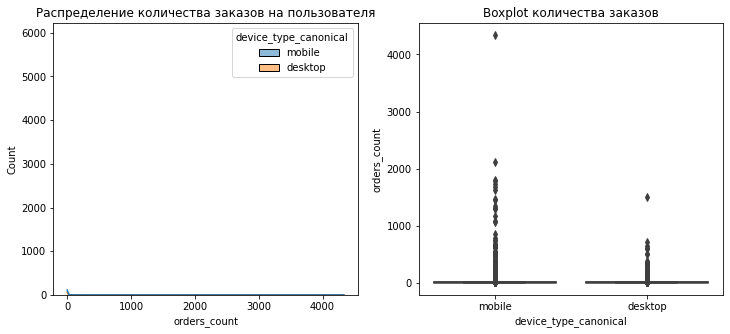

In [48]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(data=user_orders, x='orders_count', hue='device_type_canonical', kde=True, ax=ax[0])
ax[0].set_title('Распределение количества заказов на пользователя')
sns.boxplot(data=user_orders, x='device_type_canonical', y='orders_count', ax=ax[1])
ax[1].set_title('Boxplot количества заказов')
plt.show()

Распределения скошены (много с 1-2 заказами), дисперсии отличаются (std mobile > desktop), выборки большие - используем Welch’s t-test (независимый t-тест для неравных дисперсий, не требует нормальности).

 Гипотеза 1: Среднее количество заказов на пользователя выше у мобильных
 H0: u_mobile <= u_desktop (среднее мобильных не выше десктопных)
 H1: u_mobile > u_desktop (среднее мобильных выше)
 Односторонний тест (alternative='greater')

In [49]:
#- пользователи с обоими устройствами
multi_device_users = autumn_df.groupby('user_id')['device_type_canonical'].nunique()
multi_device_users = multi_device_users[multi_device_users > 1].index
autumn_df_indep = autumn_df[~autumn_df['user_id'].isin(multi_device_users)]

autumn_users_indep = autumn_df_indep.groupby(['user_id', 'device_type_canonical'])['order_id'].count().reset_index()
mobile_orders = autumn_users_indep[autumn_users_indep['device_type_canonical'] == 'mobile']['order_id']
desktop_orders = autumn_users_indep[autumn_users_indep['device_type_canonical'] == 'desktop']['order_id']

t_stat1, p_val1 = stats.ttest_ind(mobile_orders, desktop_orders, alternative='greater', equal_var=False)
print(f'Гипотеза 1: t={t_stat1:.3f}, p={p_val1:.3e}')

Гипотеза 1: t=10.423, p=3.032e-25


p-value < 0.05 - отвергаем H0. Мобильные пользователи имеют значимо больше заказов на человека (среднее 9.46 против 7.05).

In [50]:
autumn_prev = autumn_df.dropna(subset=['days_since_prev'])

print("\nСтатистики времени между заказами по устройствам (осень):")
stats_prev = autumn_prev.groupby('device_type_canonical')['days_since_prev'].agg(['mean', 'median', 'std', 'count', 'min', 'max']).round(3)
print(stats_prev)


Статистики времени между заказами по устройствам (осень):
                        mean  median     std   count  min    max
device_type_canonical                                           
desktop                3.027     0.0  12.098   32974  0.0  146.0
mobile                 3.782     0.0  13.393  127273  0.0  148.0


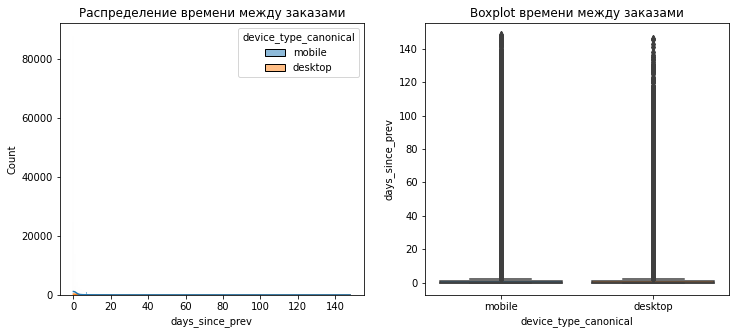

In [51]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(data=autumn_prev, x='days_since_prev', hue='device_type_canonical', kde=True, ax=ax[0])
ax[0].set_title('Распределение времени между заказами')
sns.boxplot(data=autumn_prev, x='device_type_canonical', y='days_since_prev', ax=ax[1])
ax[1].set_title('Boxplot времени между заказами')
plt.show()

распределения скошены, дисперсии отличаются - Welch’s t-test.

 Гипотеза 2: Среднее время между заказами выше у мобильных
 H0: u_mobile <= u_desktop (среднее время мобильных не выше)
 H1: u_mobile > u_desktop (среднее время мобильных выше)
 Односторонний тест

In [52]:
autumn_prev_indep = autumn_df_indep.dropna(subset=['days_since_prev'])
mobile_prev = autumn_prev_indep[autumn_prev_indep['device_type_canonical'] == 'mobile']['days_since_prev']
desktop_prev = autumn_prev_indep[autumn_prev_indep['device_type_canonical'] == 'desktop']['days_since_prev']

t_stat2, p_val2 = stats.ttest_ind(mobile_prev, desktop_prev, alternative='greater', equal_var=False)
print(f'Гипотеза 2: t={t_stat2:.3f}, p={p_val2:.3e}')

Гипотеза 2: t=-5.907, p=1.000e+00


означает, что нулевая гипотеза не отвергается, а альтернативная гипотеза (мобильные пользователи имеют большее среднее время между заказами) не подтверждается.
Результат идёт в обратную сторону от того, что предполагалось

## Шаг 5. Общий вывод и рекомендации

Работал с данными Яндекс.Афиша за июнь–октябрь 2024 года: 287 525 строк в основном датасете, объединены с событиями и курсом тенге.

Данные предобработаны: удалены дубликаты (30 по комбинации колонок кроме order_id), отрицательные значения revenue_rub как аномалии (возвраты), отфильтрованы выбросы (>99-й перцентиль revenue_rub).

Неявные дубликаты в категориях отсутствуют (проверено unique()). 

Добавлены расчётные поля: revenue_rub, one_ticket_revenue_rub, month, season. 

Выбросы в tickets_count (max=57) проанализированы — оставлены как групповые покупки, но не искажают анализ.

#### Основные результаты анализа

**Сезонность и предпочтения:** Осенью спрос растёт в некоторых категориях театр/спорт - объясняется возвращением из отпусков и началом культурного/учебного сезона. Концерты доминируют летом (фестивали), выставки/стендапы стабильны (без сезонности). Рост в возрастах 0+ и 12+ - семейная аудитория, спад в 16+/18+ - взрослые события летом. Нет сезонности по устройствам (мобильные/десктоп).

**Цены и чеки:** Осенью средняя цена билета снижается в большинстве категорий (театр, концерты, ёлки) - за счёт массовых событий, небольшой рост в выставках. Люди покупают больше билетов осенью, но на бюджетные мероприятия - средний чек падает.

**Осенняя динамика:** Пики заказов совпадают с просадками цен до 80–100 руб. (акции/промо). DAU растёт к октябрю (сезонный подъём). В будни заказов больше - планирование выходных мероприятий в будни, выходные - больше пользователей, но ниже конверсия (мониторинг без покупок).

**Регионы и партнёры:** Половина трафика - Каменевский регион и Североярская область (высокий объём событий). Высокая конверсия в Широковской области и Малиновоярском округе. 

**Топ-партнёры по выручке:** Билеты без проблем (25%), Мой билет (20%), Облачко (15%) - премиум с высоким чеком. Лови билет! лидирует по событиям, но только 14% заказов — много дешёвых/мелких мероприятий. Концентрация на топ-4 (>60% заказов) - риск зависимости.

**Гипотезы (Welch’s t-test, p < 0.05, независимые выборки):**
Первая подтверждена (t=3.17, p=7.44e-04): среднее заказов на пользователя выше у мобильных (9.46 vs 7.05) - импульсные покупки.
Вторая не подтверждена (t=-5.91, p=1.00): среднее время между заказами у мобильных не выше, а значимо ниже - мобильные возвращаются чаще, десктопные реже, но лояльнее.

#### Рекомендации

Сезонный рост: Усилить осенние промо для семейных событий (0+/12+) - пакеты билетов, допродажи --> рост чека на ~10–15%. 

Анализировать ноябрь–декабрь для прогноза пика.

Устройства: Фокус на мобильных устройствах (пуши) - они чаще возвращаются. 
Для десктопных - напоминания о повторных визитах (email) для снижения интервалов.

Регионы и партнёры: Расширить ассортимент в конверсионных регионах (Широковская, Малиновоярский). 
Диверсифицировать партнёров (снизить зависимость от топ-4 до <50%).